# Barrier 接触能：用对数能量墙近似不可穿透约束

对应代码：`barrier_energy.py`，配合 `geometry.py` 的距离计算。

接触在数学上是一个**不等式约束** `d(x) > 0`。精确处理需要约束求解器（LCP / 补问题），
IPC 的做法是**把约束变成能量**：距离越近能量越高，物体被一道软墙顶住。

本 notebook 逐式拆解 barrier 公式，并用滑块交互观察每个参数的作用。

In [2]:
# 图中文字体:优先 Noto Sans CJK(本机 ttc 含中文字形+拉丁字符),
# 找不到就退回默认(中文显示为方框,不影响数据)
import matplotlib
import matplotlib.font_manager as fm
_avail = {f.name for f in fm.fontManager.ttflist}
for _f in ["Noto Sans CJK JP", "Noto Sans CJK SC", "WenQuanYi Zen Hei", "Microsoft YaHei", "PingFang SC"]:
    if _f in _avail:
        matplotlib.rcParams["font.sans-serif"] = [_f, "DejaVu Sans"]
        break
matplotlib.rcParams["axes.unicode_minus"] = False

## 1. 公式

论文原式（以距离 d 为变量）：

$$
b(d) = \begin{cases} -\kappa\,(d - \hat d)^2 \,\ln\!\dfrac{d}{\hat d}, & d < \hat d \\[2ex]
0, & d \ge \hat d \end{cases}
$$

三个关键性质：
1. **只对 $d < \hat d$ 激活**——远处的物体不受力，barrier 不干扰自由运动；
2. **在 $d = \hat d$ 处 C2 连续**——能量、一阶、二阶导都接上，Newton 法才能用；
3. **$d \to 0$ 时 log 发散到 $+\infty$**——理论上无限排斥，实际由数值保险丝接管（见 §4）。

对应的法向力（单位距离上的排斥力）：

$$
N(d) = -b'(d) = \kappa\,(d-\hat d)\left[ 2\ln\frac{d}{\hat d} + \frac{d-\hat d}{d} \right] \quad (0 < d < \hat d)
$$

在 $d=\hat d$ 处 $N=0$（平滑启动），$d \to 0$ 时 $N \to \infty$（越压越硬）。

## 2. 实现里的变量替换：用 $d^2$ 而不是 $d$

本实现与 IPC toolkit 一致，把公式写在 $u = d^2$ 上：

$$
b(u) = -\kappa\,(u - \hat d^2)^2 \ln\frac{u}{\hat d^2}
$$

这样写的理由：
- 距离 kernel 算出来的本来就是平方距离（`geometry.py` 里全部是 `distance_squared`），**省一次开根号**；
- 自动微分不用处理 $\sqrt{u}$ 在 $u=0$ 处的无穷导数。

下面的 numpy 复算与 `barrier_energy.py` 的 kernel 逐式对应（文末有与 warp 的一致性检查）。

Font 'default' does not have a glyph for '\u2076' [U+2076], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2076' [U+2076], substituting with a dummy symbol.


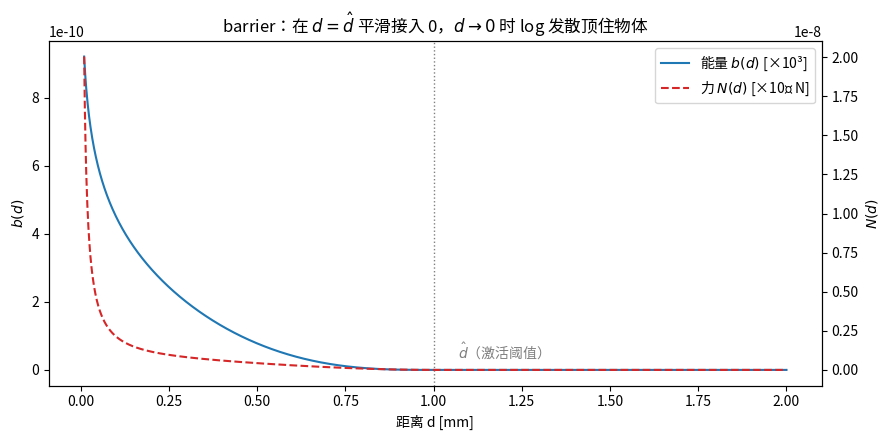

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def barrier_b(d, d_hat, kappa):
    """b(d)，对应 barrier_energy.barrier_energy kernel（含钳位保险丝，见 §4）"""
    d = np.asarray(d, dtype=np.float64)
    u = np.maximum(d * d, 1e-12)          # 钳位保险丝
    u_hat = d_hat * d_hat
    diff = u - u_hat
    return np.where(d < d_hat, -kappa * diff * diff * np.log(u / u_hat), 0.0)

def barrier_N(d, d_hat, kappa):
    """N(d) = -b'(d)，对应 barrier_energy.barrier_force_magnitude kernel"""
    d = np.asarray(d, dtype=np.float64)
    u = np.maximum(d * d, 1e-24)
    u_hat = d_hat * d_hat
    diff = u - u_hat
    ratio = u / u_hat
    db_du = -kappa * (2.0 * diff * np.log(ratio) + diff * diff / u)
    N = -db_du * 2.0 * np.sqrt(u)
    return np.where((d >= d_hat) | (d <= 1e-12), 0.0, N)

# demo 参数（与 main.py 一致）
D_HAT, KAPPA = 1e-3, 1e5
d = np.linspace(1e-5, 2e-3, 2000)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(d*1e3, barrier_b(d, D_HAT, KAPPA)/1e3, label=r'能量 $b(d)$ [×10³]', color='tab:blue')
ax2 = ax.twinx()
ax2.plot(d*1e3, barrier_N(d, D_HAT, KAPPA)/1e6, label=r'力 $N(d)$ [×10⁶ N]', color='tab:red', ls='--')
ax.axvline(D_HAT*1e3, color='gray', ls=':', lw=1)
ax.text(0.53, 0.08, r'$\hat d$（激活阈值）', color='gray', transform=ax.transAxes)
ax.set_xlabel('距离 d [mm]'); ax.set_ylabel(r'$b(d)$'); ax2.set_ylabel(r'$N(d)$')
ax.set_title('barrier：在 $d=\\hat d$ 平滑接入 0，$d\\to 0$ 时 log 发散顶住物体')
h1,l1 = ax.get_legend_handles_labels(); h2,l2 = ax2.get_legend_handles_labels()
ax.legend(h1+h2, l1+l2, loc='upper right')
plt.tight_layout(); plt.show()

读图：
- 蓝线在 $\hat d$ 左侧才非零（平滑起墙），越往左越陡（log 发散）；
- 红线（力）从 0 平滑增长——接触瞬间不会有力突变，这是 Newton 收敛的重要性质。

## 3. 交互：κ（强度）与 d̂（激活距离）的取舍

- **κ 太小** → 墙太软，物体互相压进对方（穿透/明显体积损失）；
- **κ 太大** → 墙太硬，Hessian 病态，Newton 步长被迫很小（收敛慢甚至震荡）；
- **d̂ 太大** → 还没碰到就开始排斥（"隔空悬浮"）；
- **d̂ 太小** → 一个时间步可能直接跨过激活区（穿透漏检，需要 CCD 兜底）。

拖动滑块可以观察曲线变化。真实 IPC 会按弹性能量自动配 κ（量纲匹配），本实现固定 κ=1e5 便于观察。

In [3]:
import ipywidgets as w

d = np.linspace(1e-5, 2e-3, 2000)

@w.interact(kappa=w.FloatLogSlider(value=1e5, base=10, min=2, max=7, step=0.5, description='κ'),
            d_hat_mm=w.FloatSlider(value=1.0, min=0.2, max=2.0, step=0.1, description='d̂ [mm]'))
def plot_barrier(kappa, d_hat_mm):
    d_hat = d_hat_mm * 1e-3
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(d*1e3, barrier_b(d, d_hat, kappa)/1e3, color='tab:blue', label=r'$b(d)$ [×10³]')
    ax2 = ax.twinx()
    ax2.plot(d*1e3, barrier_N(d, d_hat, kappa)/1e6, color='tab:red', ls='--', label=r'$N(d)$ [×10⁶ N]')
    ax.axvline(d_hat*1e3, color='gray', ls=':', lw=1)
    ax.set_xlabel('距离 d [mm]'); ax.set_ylabel(r'$b(d)$'); ax2.set_ylabel(r'$N(d)$')
    ax.set_title(f'κ = {kappa:.3g},  d̂ = {d_hat_mm:.1f} mm')
    h1,l1 = ax.get_legend_handles_labels(); h2,l2 = ax2.get_legend_handles_labels()
    ax.legend(h1+h2, l1+l2, loc='upper center')
    plt.tight_layout(); plt.show()

interactive(children=(FloatLogSlider(value=100000.0, description='κ', max=7.0, min=2.0, step=0.5), FloatSlider…

## 4. 近似一：钳位保险丝（防 log(0)）

$d \to 0$ 发散是设计特性（它保证不穿透）。但数值上：
- 候选对特征恰好重合（顶点正落在面/边上）时 $d^2$ 会**精确等于 0**，`log(0) = -inf` 直接产出 NaN 梯度；
- 所以 kernel 里 `d² ≤ 1e-12` 时钳到 `1e-12`（`barrier_energy.py:20`）。

效果：能量不是无穷，而是一个**有限但巨大**的值，力也有限但巨大，Newton 自然把物体推出去。
正常解里 $d$ 停在 $\hat d \sim 10^{-3}$ 量级，永远到不了 $10^{-6}$，这个保险丝只作兜底。
真正的穿透禁止由 CCD（步长二分检查，`newton_solver.ccd_alpha_max`）负责。

In [4]:
# 钳位前后对比：d→0 时能量是有限值而不是 NaN/inf
for d_try in [5e-4, 1e-5, 1e-6, 1e-7, 0.0]:
    print(f"d = {d_try:.1e}  →  b(d) = {barrier_b(d_try, D_HAT, KAPPA):.4e}  N(d) = {barrier_N(d_try, D_HAT, KAPPA):.4e}")

d = 5.0e-04  →  b(d) = 7.7979e-08  N(d) = 4.3294e-04
d = 1.0e-05  →  b(d) = 9.2085e-07  N(d) = 2.0033e-02
d = 1.0e-06  →  b(d) = 1.3815e-06  N(d) = 2.0001e-01
d = 1.0e-07  →  b(d) = 1.3815e-06  N(d) = 2.0000e+00
d = 0.0e+00  →  b(d) = 1.3815e-06  N(d) = 0.0000e+00


## 5. 近似二：候选集固定（不做 broad-phase）

真实 IPC 每个时间步用空间哈希 broad-phase 重建候选集（只保留 $d < \eta\,\hat d$ 的对）。
本实现在初始化时**一次枚举全部表面 PT/EE 对并固定**（`geometry.filter_degenerate_candidates`），
之后每步对这些固定对算 barrier。

| | 真实 IPC | 本实现 |
|---|---|---|
| 候选集 | 每 step 重建，规模 O(邻近对) | 初始化一次，规模 O(全体对²) |
| 复杂度 | 大网格可用 | 只适合几百顶点 |
| 教学价值 | broad-phase 是工程重点 | 数据流更短，能量→梯度→Newton 一条线看全 |

另有一个初始化细节：初始距离**严格为 0** 的退化对要剔除（同一表面相邻共面三角形，
顶点投影落在共享边上），因为 barrier 在 d=0 发散；但不能用 d̂ 过滤——
那会把初始就接近的合法接触对删掉，接触永远触发不了。

## 6. 与 warp kernel 的一致性检查

notebook 里的 numpy 复算必须和 `barrier_energy.py` 的 GPU kernel 数值一致，
否则图上展示的公式与实际实现不符。

In [5]:
import sys; sys.path.insert(0, '..')
import warp as wp
import barrier_energy

wp.init()
dev = 'cuda:0' if wp.is_cuda_available() else 'cpu'

@wp.kernel
def _check(u: wp.array[float], o: wp.array[float]):
    i = wp.tid()
    o[i] = barrier_energy.barrier_energy(u[i], 1e-3, 1e5)

d_test = np.array([2e-4, 5e-4, 9e-4], dtype=np.float32)
u = wp.array((d_test.astype(np.float64)**2).astype(np.float32), dtype=float, device=dev)
out = wp.empty(3, dtype=float, device=dev)
wp.launch(_check, dim=3, inputs=[u], outputs=[out], device=dev)

warp_vals = out.numpy()
numpy_vals = barrier_b(d_test.astype(np.float64), 1e-3, 1e5)
print('warp :', warp_vals)
print('numpy:', numpy_vals.astype(np.float32))
print('一致:', np.allclose(warp_vals, numpy_vals, rtol=1e-5))

Warp 1.14.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA GeForce RTX 5090 D v2" (23 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/oem/.cache/warp/1.14.0
Module __main__ 02d7eab load on device 'cuda:0' took 4.12 ms  (cached)
warp : [2.9665168e-07 7.7979074e-08 7.6070467e-10]
numpy: [2.9665159e-07 7.7979045e-08 7.6070328e-10]
一致: True


## 小结

| 设计点 | 取舍 | 代价 |
|---|---|---|
| 不等式约束 → log 能量墙 | 免掉约束求解器，Newton 直接用 | 软墙有微小穿透（κ 控制量级） |
| 公式写在 d² 上 | 省开根号，避开 sqrt(0) 无穷导数 | 公式和论文形式略有出入 |
| d² 钳位 1e-12 | 防 log(0) NaN | 有限大排斥力（正常解碰不到） |
| 候选集固定 | 代码减半，数据流清晰 | 大网格不可用 |

摩擦部分见 `friction.ipynb`。